In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

In [4]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment.isnull().sum()
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [6]:
trades.duplicated().sum()

np.int64(0)

Missing Value Analysis

Isnull () . sum was used to check both datasets against missing values.

Observation:
The trader dataset did not have any missing values that could be identified, and therefore it can be considered complete and can be analyzed without further imputation and cleaning procedures.

In [7]:
sentiment.shape
trades.shape


(211224, 16)

In [8]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [11]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date'] = trades['Timestamp IST'].dt.date

In [12]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [14]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [15]:
sentiment.columns = sentiment.columns.str.strip()

In [16]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [17]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [18]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [20]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [21]:
sentiment = sentiment.rename(columns={
    'Date': 'date',
    'Classification': 'sentiment'
})

In [22]:
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True).dt.date

In [24]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [25]:
df = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [26]:
df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Data Integration

The date column was used to merge the trader dataset and the market sentiment dataset.

Every trade is currently assigned with the market sentiment classification (Fear or Greed), which enables us to study how the behavior of trader evolves with various sentiment regimes.

1. PERFORMANCE ANALYSIS

##DAILY PNL

In [28]:
df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='str')

In [29]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [30]:
df.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification'],
      dtype='str')

In [31]:
daily_pnl = df.groupby(['account','date'])['closed_pnl'].sum().reset_index()
daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


##WIN RATE

In [32]:
df['win'] = df['closed_pnl'] > 0

In [33]:
df.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

PNL VS SENTIMENT

Text(0.5, 1.0, 'Trader Profitability under Fear vs Greed')

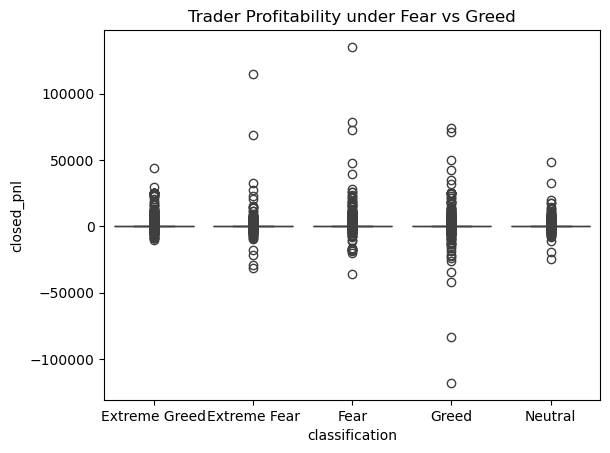

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("Trader Profitability under Fear vs Greed")

INSIGHT 1 : PnL variance is significantly higher during Greed periods, suggesting traders take more aggressive positions when sentiment is positive.


2.BEHAVIOUR ANALYSIS

##TRADERS PER DAY

In [34]:
trades_per_day = df.groupby(['date','classification']).size().reset_index(name='trades')
trades_per_day.head()

,date,classification,trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


In [35]:
pd.crosstab(df['side'], df['classification'], normalize='columns')

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
side,,,,,
BUY,0.510981,0.44859,0.489513,0.488559,0.503343
SELL,0.489019,0.55141,0.510487,0.511441,0.496657


In [36]:
df.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

TRADE SIZE VS SENTIMENTS

Text(0.5, 1.0, 'Trade Size by Market Sentiment')

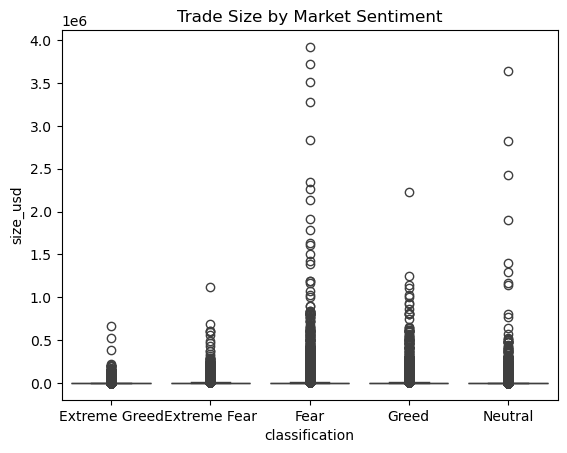

In [38]:
sns.boxplot(x='classification', y='size_usd', data=df)
plt.title("Trade Size by Market Sentiment")

TRADE FREQUENCY

Text(0.5, 1.0, 'Trade Frequency by Market Sentiment')

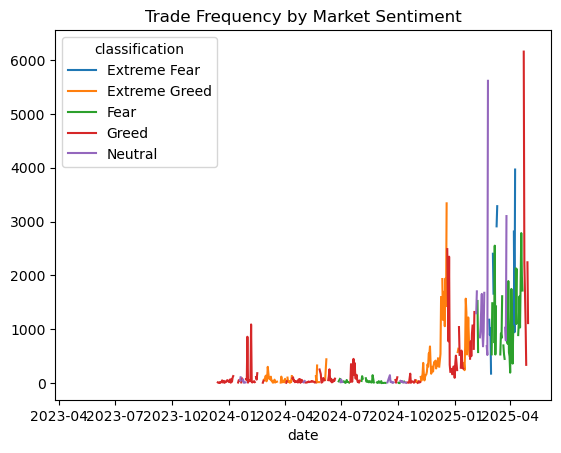

In [39]:
df.groupby(['date','classification']).size().unstack().plot()
plt.title("Trade Frequency by Market Sentiment")

3. TRADER SEGMENTATION

HIGH VS LOW TRADE SIZE

In [41]:
df['size_segment'] = df['size_usd'].apply(lambda x: 'high' if x > df['size_usd'].median() else 'low')

In [59]:
df.groupby('size_segment')['closed_pnl'].mean()

size_segment
high    93.116556
low      4.381445
Name: closed_pnl, dtype: float64

This means Large trade size is associated with higher profitability.

In [60]:
df.groupby('size_segment')['win'].mean()

size_segment
high    0.41536
low     0.40717
Name: win, dtype: float64

Text(0.5, 1.0, 'Trader Profitability by Trade Size Segment')

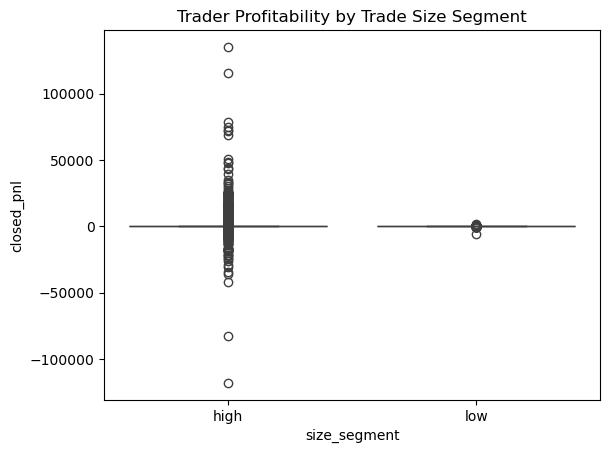

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='size_segment', y='closed_pnl', data=df)
plt.title("Trader Profitability by Trade Size Segment")

Insight 2- High trade size segments exhibit higher average profitability but also larger PnL volatility, suggesting that larger position sizes are associated with increased risk-taking.


FREQUENT VS INFREQUENT TRADERS

In [50]:
trade_counts = df.groupby('account').size()

df['activity_segment'] = df['account'].map(
    lambda x: 'frequent' if trade_counts[x] > trade_counts.median() else 'infrequent'
)

In [56]:
df.groupby('activity_segment')['closed_pnl'].mean()

activity_segment
frequent      42.493421
infrequent    96.943024
Name: closed_pnl, dtype: float64

In [57]:
df.groupby('activity_segment')['size_usd'].mean()

activity_segment
frequent      5800.826314
infrequent    4396.190601
Name: size_usd, dtype: float64

Text(0.5, 1.0, 'Trader Performance by Activity Level')

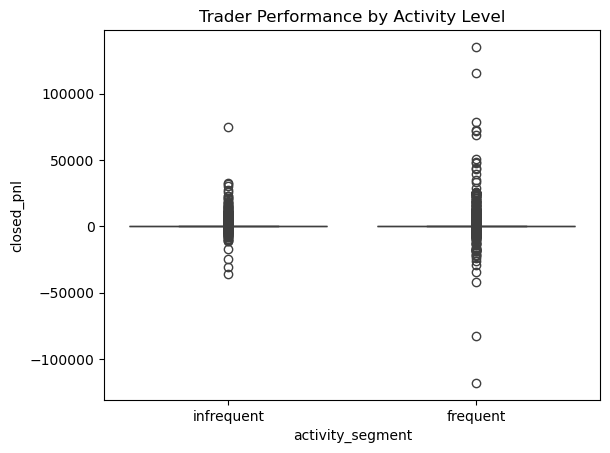

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='activity_segment', y='closed_pnl', data=df)
plt.title("Trader Performance by Activity Level")

Insight 3-
Frequent traders exhibit higher volatility in PnL compared to infrequent traders. 
This suggests that increased trading activity may lead to higher risk exposure and potentially overtrading behavior.

##Strategy
1.During Fear sentiment, traders should reduce position size to limit downside risk.
2.Momentum traders may benefit from higher trade activity during Greed periods.

